In [1]:
#Importamos las librerias pandas, numpy y matplotlib respectivamente
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
#Carga desde un archivo .csv sin indice
data = pd.read_csv('Ventas_Piso_Mensual_Limpia.csv') 

In [3]:
#Verificamos información del DataFrame
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 31 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Piso            9 non-null      str    
 1   Febrero, 24     6 non-null      float64
 2   Marzo, 24       7 non-null      float64
 3   Abril, 24       7 non-null      float64
 4   Mayo, 24        7 non-null      float64
 5   Junio, 24       7 non-null      float64
 6   Julio, 24       8 non-null      float64
 7   Agosto, 24      8 non-null      float64
 8   Septiembre, 24  8 non-null      float64
 9   Octubre, 24     8 non-null      float64
 10  Noviembre, 24   8 non-null      float64
 11  Diciembre, 24   8 non-null      float64
 12  Enero, 25       9 non-null      float64
 13  Febrero, 25     9 non-null      float64
 14  Marzo, 25       9 non-null      float64
 15  Abril, 25       9 non-null      float64
 16  Mayo, 25        9 non-null      float64
 17  Junio, 25       9 non-null      float64
 18  Julio

Debido a la forma del dataset, los outliers al sacarse por columna, pero cada fila siendo una variable. Se decide normalizar la base de datos a un formato tidy.

In [10]:
df_tidy = data.set_index('Piso ').T.reset_index()

df_tidy = df_tidy.rename(columns={
    'index': 'Fecha'
})

In [9]:
df_tidy.head()

Piso,Fecha,Leads,Efectivos,SDC,PDM,Citas Programadas,Citas Efectivas,Ventas,Conversion,Aporte
0,"Febrero, 24",329.0,NaN,NaN,22.0,9.0,4.0,9.0,0.027356,NaN
1,"Marzo, 24",19.0,NaN,NaN,13.0,28.0,16.0,4.0,0.210526,0.333333
2,"Abril, 24",76.0,NaN,NaN,35.0,15.0,6.0,10.0,0.131579,1.428571
3,"Mayo, 24",87.0,NaN,NaN,40.0,38.0,16.0,1.0,0.011494,0.125000
4,"Junio, 24",55.0,NaN,NaN,28.0,78.0,60.0,3.0,0.054545,0.230769


División de las columnas cualitativas y cuantitativas para la búsqueda de los outlier

In [11]:
#Creo 2 dataframe para poder procesar los outliers, separando las variables cualitativas de las cuantitativas
cualitativas = df_tidy['Fecha']
cuantitativas = df_tidy.iloc[:, 1:10]

In [12]:
#Se corroboran los dataframes creados
cualitativas.head()

0    Febrero, 24
1      Marzo, 24
2      Abril, 24
3       Mayo, 24
4      Junio, 24
Name: Fecha, dtype: str

In [13]:
#Se corroboran los dataframes creados
cuantitativas.info()

<class 'pandas.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Leads               30 non-null     float64
 1   Efectivos           19 non-null     float64
 2   SDC                 25 non-null     float64
 3   PDM                 30 non-null     float64
 4   Citas Programadas   30 non-null     float64
 5   Citas Efectivas     30 non-null     float64
 6   Ventas              30 non-null     float64
 7   Conversion          30 non-null     float64
 8   Aporte              29 non-null     float64
dtypes: float64(9)
memory usage: 2.2 KB


Identificamos outliers

<Figure size 1500x800 with 0 Axes>

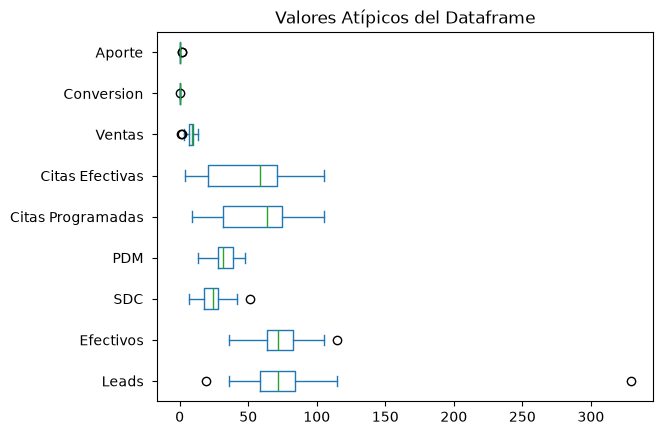

In [14]:
#Realizamos diagrama de caja o bigote de cada columna del dataframe
fig = plt.figure(figsize =(15, 8))
cuantitativas.plot(kind='box', vert=False)
plt.title("Valores Atípicos del Dataframe")
plt.show() #dibujamos el diagrama

In [15]:
#Método aplicando Cuartiles. Encuentro cuartiles 0.25 y 0.75
y=cuantitativas

percentile25=y.quantile(0.25) #Q1
percentile75=y.quantile(0.75) #Q3
iqr= percentile75 - percentile25

Limite_Superior_iqr= percentile75 + 1.5*iqr
Limite_Inferior_iqr= percentile25 - 1.5*iqr
print("Limite superior permitido", Limite_Superior_iqr)
print("Limite inferior permitido", Limite_Inferior_iqr)

Limite superior permitido Piso 
Leads                 122.625000
Efectivos             111.000000
SDC                    43.000000
PDM                    55.500000
Citas Programadas     138.625000
Citas Efectivas       146.750000
Ventas                 14.500000
Conversion              0.231259
Aporte                  0.670732
dtype: float64
Limite inferior permitido Piso 
Leads                 19.625000
Efectivos             35.000000
SDC                    3.000000
PDM                   11.500000
Citas Programadas    -32.375000
Citas Efectivas      -55.250000
Ventas                 2.500000
Conversion            -0.016023
Aporte                -0.051220
dtype: float64


In [17]:
#Obtenemos datos limpios del Dataframe
data1_iqr= cuantitativas[(y<=Limite_Superior_iqr)&(y>=Limite_Inferior_iqr)]
data1_iqr.head()

Piso,Leads,Efectivos,SDC,PDM,Citas Programadas,Citas Efectivas,Ventas,Conversion,Aporte
0,NaN,NaN,NaN,22.0,9.0,4.0,9.0,0.027356,NaN
1,NaN,NaN,NaN,13.0,28.0,16.0,4.0,0.210526,0.333333
2,76.0,NaN,NaN,35.0,15.0,6.0,10.0,0.131579,NaN
3,87.0,NaN,NaN,40.0,38.0,16.0,NaN,0.011494,0.125000
4,55.0,NaN,NaN,28.0,78.0,60.0,3.0,0.054545,0.230769


In [18]:
#Corroboramos valores nulos del dataframe LIMPIO
valores_nulos=data1_iqr.isnull().sum()
valores_nulos

Piso 
Leads                  2
Efectivos             12
SDC                    6
PDM                    0
Citas Programadas      0
Citas Efectivas        0
Ventas                 2
Conversion             1
Aporte                 3
dtype: int64

In [19]:
#Reemplazamos valores atípicos (nulos) del dataframe con "mean"
#Realizamos una copia del dataframe
data2_iqr=data1_iqr.copy()
data2_iqr=data2_iqr.fillna(round(data1_iqr.median(),1))
data2_iqr.head()

Piso,Leads,Efectivos,SDC,PDM,Citas Programadas,Citas Efectivas,Ventas,Conversion,Aporte
0,71.5,71.5,23.5,22.0,9.0,4.0,9.0,0.027356,0.300000
1,71.5,71.5,23.5,13.0,28.0,16.0,4.0,0.210526,0.333333
2,76.0,71.5,23.5,35.0,15.0,6.0,10.0,0.131579,0.300000
3,87.0,71.5,23.5,40.0,38.0,16.0,9.0,0.011494,0.125000
4,55.0,71.5,23.5,28.0,78.0,60.0,3.0,0.054545,0.230769


In [20]:
# Unimos el dataframe cuantitativo limpio con el dataframe cualitativo

Datos_limpios = pd.concat([cualitativas, data2_iqr], axis=1)
Datos_limpios.head()

,Fecha,Leads,Efectivos,SDC,PDM,Citas Programadas,Citas Efectivas,Ventas,Conversion,Aporte
0,"Febrero, 24",71.5,71.5,23.5,22.0,9.0,4.0,9.0,0.027356,0.300000
1,"Marzo, 24",71.5,71.5,23.5,13.0,28.0,16.0,4.0,0.210526,0.333333
2,"Abril, 24",76.0,71.5,23.5,35.0,15.0,6.0,10.0,0.131579,0.300000
3,"Mayo, 24",87.0,71.5,23.5,40.0,38.0,16.0,9.0,0.011494,0.125000
4,"Junio, 24",55.0,71.5,23.5,28.0,78.0,60.0,3.0,0.054545,0.230769


In [21]:
#Corroboramos valores nulos del dataframe LIMPIO
valores_nulos=Datos_limpios.isnull().sum()
valores_nulos

Fecha                 0
Leads                 0
Efectivos             0
SDC                   0
PDM                   0
Citas Programadas     0
Citas Efectivas       0
Ventas                0
Conversion            0
Aporte                0
dtype: int64

In [22]:
#Convertir DataFrame a CSV
Datos_limpios.to_csv("Ventas_Piso_Mensual_sin_outliers.csv")